# Install Dependencies

In [49]:
!pip install -r dependencies.txt

In [50]:
import numpy as np
import gym
import pickle
import matplotlib.pyplot as plt

import random
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from collections import deque

from gym import logger as gymlogger
from gym.wrappers import RecordVideo
gymlogger.set_level(40) #error only
import glob
import io
import base64
from IPython.display import HTML
from IPython import display as ipythondisplay

def show_video():
  mp4list = glob.glob('video/*.mp4')
  if len(mp4list) > 0:
    mp4 = mp4list[0]
    video = io.open(mp4, 'r+b').read()
    encoded = base64.b64encode(video)
    ipythondisplay.display(HTML(data=''''''.format(encoded.decode('ascii'))))
  else:
    print("Could not find video")

# Initialize CartPole Environment

In [51]:
# observation space

env = gym.make('CartPole-v1')
print("CartPole Environment:")
print("Shape of observation space: ", env.observation_space.shape[0])
print(f"Observation Space: {env.observation_space}")
print(f"Action Space: {env.action_space}")

CartPole Environment:
Shape of observation space:  4
Observation Space: Box([-4.8000002e+00 -3.4028235e+38 -4.1887903e-01 -3.4028235e+38], [4.8000002e+00 3.4028235e+38 4.1887903e-01 3.4028235e+38], (4,), float32)
Action Space: Discrete(2)


# Task 1: Development of an RL Agent

Demonstrate the correctness of the implementation by sampling a random state from the cart pole environment, inputting to the agent, and outputting a chosen action. Print the values of the state and chosen action in Jupyter notebook.



## 1.1 DEEP Q-Learning (DQL) Agent for CartPole

- Uses a neural network instead of a Q-table.
- Implements experience replay to improve stability.
- Uses a target network to stabilize learning.
- Uses epsilon-greedy policy for exploration.

### DQL Implementation

In [60]:
# Neural Network for Q-value approximation
class DQN(nn.Module):
    def __init__(self, state_size, action_size):
        super(DQN, self).__init__()
        self.fc1 = nn.Linear(state_size, 128)  # Increased from 64 to 128
        self.fc2 = nn.Linear(128, 128)         # Increased from 64 to 128
        self.fc3 = nn.Linear(128, action_size)
        
        # Initialize weights for better training
        nn.init.xavier_uniform_(self.fc1.weight)
        nn.init.xavier_uniform_(self.fc2.weight)
        nn.init.xavier_uniform_(self.fc3.weight)

    def forward(self, state):
        x = F.relu(self.fc1(state))
        x = F.relu(self.fc2(x))
        return self.fc3(x)

class DQLAgent:
    def __init__(self, env, gamma=0.99, lr=0.0005, batch_size=128, memory_size=20000,
                 epsilon=1.0, epsilon_decay=0.99, epsilon_min=0.01, target_update_freq=5):
        self.env = env
        self.state_size = env.observation_space.shape[0]
        self.action_size = env.action_space.n
        self.gamma = gamma  # Discount factor
        self.epsilon = epsilon  # Exploration rate
        self.epsilon_decay = epsilon_decay  # Decay rate for epsilon
        self.epsilon_min = epsilon_min  # Minimum exploration rate
        self.batch_size = batch_size  # Batch size for training
        self.target_update_freq = target_update_freq  # Target network update frequency
        self.lr = lr  # Store learning rate

        # Memory for experience replay
        self.memory = deque(maxlen=memory_size)

        # Q-network (main network)
        self.q_network = DQN(self.state_size, self.action_size)
        self.target_network = DQN(self.state_size, self.action_size)
        self.target_network.load_state_dict(self.q_network.state_dict())  # Copy weights
        self.target_network.eval()  # Target network does not update with gradients

        # Optimizer with custom learning rate
        self.optimizer = optim.Adam(self.q_network.parameters(), lr=lr)

    def set_learning_rate(self, new_lr):
        """ Update the learning rate of the optimizer dynamically. """
        for param_group in self.optimizer.param_groups:
            param_group['lr'] = new_lr

    def select_action(self, state, training=True):
        """ Select action using epsilon-greedy policy """
        if training and np.random.rand() < self.epsilon:
            return self.env.action_space.sample()  # Random action
        else:
            state_tensor = torch.FloatTensor(state).unsqueeze(0)
            with torch.no_grad():
                q_values = self.q_network(state_tensor)
            return torch.argmax(q_values).item()

    def store_experience(self, state, action, reward, next_state, done):
        """ Store experience in replay memory with uniform shapes """
        self.memory.append((
            np.array(state, dtype=np.float32).reshape(self.state_size),  # Ensure shape (4,)
            action,
            reward,
            np.array(next_state, dtype=np.float32).reshape(self.state_size),  # Ensure shape (4,)
            done
        ))

    def train_step(self):
        """ Train the agent using a batch of experiences """
        if len(self.memory) < self.batch_size:
            return

        # Sample mini-batch from memory
        batch = random.sample(self.memory, self.batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)

        # Convert states and next_states to uniform NumPy arrays before stacking
        states = torch.FloatTensor(np.array(states, dtype=np.float32).reshape(self.batch_size, -1))
        actions = torch.LongTensor(np.array(actions)).unsqueeze(1)
        rewards = torch.FloatTensor(np.array(rewards)).unsqueeze(1)
        next_states = torch.FloatTensor(np.array(next_states, dtype=np.float32).reshape(self.batch_size, -1))
        dones = torch.FloatTensor(np.array(dones)).unsqueeze(1)

        # Compute Q-values
        q_values = self.q_network(states).gather(1, actions)

        # Compute target Q-values
        with torch.no_grad():
            next_q_values = self.target_network(next_states).max(1)[0].unsqueeze(1)
            target_q_values = rewards + (self.gamma * next_q_values * (1 - dones))

        # Compute loss
        loss = F.mse_loss(q_values, target_q_values)

        # Backpropagation
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

    def train(self, num_episodes=1000):
        """ Train the agent using Deep Q-Learning with improvements """
        rewards_per_episode = []
        recent_rewards = deque(maxlen=10)  # Changed from 100 to 10
        last_10_rewards = deque(maxlen=10)  # For early stopping based on last 10 episodes
        
        for episode in range(num_episodes):
            reset_output = self.env.reset()
            
            # Check if Gym returns (state, info) or just state
            if isinstance(reset_output, tuple):
                state = reset_output[0]  # Gymnasium (state, info)
            else:
                state = reset_output  # Older Gym versions
                
            state = np.array(state, dtype=np.float32).reshape(-1)  # Flatten state
            total_reward = 0
            done = False
            
            while not done:
                action = self.select_action(state)
                
                # Handle both Gym and Gymnasium versions
                step_result = self.env.step(action)
                if len(step_result) == 4:
                    next_state, reward, done, info = step_result
                else:
                    next_state, reward, done, truncated, info = step_result
                    done = done or truncated  # Merge `done` and `truncated` flags
                    
                next_state = np.array(next_state, dtype=np.float32).reshape(-1)
                self.store_experience(state, action, reward, next_state, done)
                state = next_state
                total_reward += reward
                
                self.train_step()
                
            rewards_per_episode.append(total_reward)
            recent_rewards.append(total_reward)
            last_10_rewards.append(total_reward)  # Add to last 10 tracking
            
            # Update target network
            if episode % self.target_update_freq == 0:
                self.target_network.load_state_dict(self.q_network.state_dict())
                
            # Decay epsilon
            self.epsilon = max(self.epsilon * self.epsilon_decay, self.epsilon_min)
            
            # Learning rate scheduler
            if episode > 0 and episode % 100 == 0:
                avg_recent = sum(recent_rewards) / len(recent_rewards) if recent_rewards else 0
                if avg_recent < 150:  # If performance is lagging
                    new_lr = self.lr * 0.5
                    self.set_learning_rate(new_lr)
                    self.lr = new_lr
                    print(f"Reducing learning rate to {new_lr}")
            
            # Print progress every 10 episodes
            if episode % 10 == 0:
                avg_reward = sum(recent_rewards) / len(recent_rewards) if recent_rewards else 0
                
                # Calculate last 10 average
                last_10_avg = sum(last_10_rewards) / len(last_10_rewards) if last_10_rewards else 0
                
                print(f"Episode {episode}/{num_episodes}, Total Reward: {total_reward}, Avg(last {len(recent_rewards)}): {avg_reward:.2f}, Epsilon: {self.epsilon:.3f}")
                
                # Early stopping if last 10 episodes have average reward above 220
                # Check if all of the last 10 episodes have reward > 195 AND the average is > 220
                if len(last_10_rewards) == 10 and last_10_avg > 220 and all(reward > 195 for reward in last_10_rewards):
                    print(f"Early stopping at episode {episode} with last 10 episodes average reward {last_10_avg:.2f}")
                    print(f"All of the last 10 episodes exceeded the 195 threshold")
                    break
                    
        self.plot_rewards(rewards_per_episode)
        return rewards_per_episode  # Return for evaluation

    def test(self, num_episodes=10):
        """ Test the agent without training """
        for episode in range(num_episodes):
            reset_output = self.env.reset()

            # Check if Gym returns (state, info) or just state
            if isinstance(reset_output, tuple):
                state = reset_output[0]  # Gymnasium (state, info)
            else:
                state = reset_output  # Older Gym versions

            state = np.array(state, dtype=np.float32).reshape(-1)  # Ensure state is (4,)
            total_reward = 0
            done = False

            while not done:
                action = self.select_action(state, training=False)

                step_result = self.env.step(action)
                if len(step_result) == 4:
                    next_state, reward, done, info = step_result
                else:
                    next_state, reward, done, truncated, info = step_result
                    done = done or truncated  # Merge `done` and `truncated` flags

                state = np.array(next_state, dtype=np.float32).reshape(-1)  # Ensure next state is (4,)
                total_reward += reward

            print(f"Episode {episode+1}, Total Reward: {total_reward}")

    def plot_rewards(self, rewards):
        """ Plot the rewards over episodes """
        plt.figure(figsize=(10, 6))
        plt.plot(rewards)
        plt.xlabel('Episodes')
        plt.ylabel('Rewards')
        plt.title('Training Rewards over Episodes')
        plt.grid(True)
        plt.show()

    def save_model(self, filename='dql_cartpole.pth'):
        """ Save trained model """
        torch.save(self.q_network.state_dict(), filename)

    def load_model(self, filename='dql_cartpole.pth'):
        """ Load trained model """
        self.q_network.load_state_dict(torch.load(filename))
        self.target_network.load_state_dict(self.q_network.state_dict())
        self.q_network.eval()
        self.target_network.eval()

# Task 1: Demonstrate agent action on a random state
def demonstrate_agent_action(agent, env):
    print("\n--- Task 1: Demonstrating Agent Action Selection ---")
    # Reset the environment to get a random state
    state = env.reset()
    if isinstance(state, tuple):
        state = state[0]
    
    # Print the state values
    print("Random state from environment:")
    print(f"  Cart Position: {state[0]:.6f}")
    print(f"  Cart Velocity: {state[1]:.6f}")
    print(f"  Pole Angle: {state[2]:.6f}")
    print(f"  Pole Angular Velocity: {state[3]:.6f}")
    
    # Get and print action
    action = agent.select_action(state, training=False)
    action_name = "Left" if action == 0 else "Right"
    print(f"Agent's chosen action: {action} ({action_name})")
    
    return state, action

# Task 2: Evaluate agent over 100 episodes
def evaluate_agent(agent, env, num_episodes=100):
    """
    Enhanced evaluation function that builds on your existing evaluate_agent
    with additional useful metrics.
    """
    print("\n=== Enhanced Agent Evaluation ===")
    rewards = []
    episode_lengths = []
    actions_distribution = [0, 0]  # Count of [left, right] actions
    
    for episode in range(num_episodes):
        state = env.reset()
        if isinstance(state, tuple):
            state = state[0]
        
        state = np.array(state, dtype=np.float32).reshape(-1)
        total_reward = 0
        done = False
        steps = 0
        
        while not done:
            action = agent.select_action(state, training=False)
            actions_distribution[action] += 1
            
            step_result = env.step(action)
            if len(step_result) == 4:
                next_state, reward, done, info = step_result
            else:
                next_state, reward, done, truncated, info = step_result
                done = done or truncated
                
            state = np.array(next_state, dtype=np.float32).reshape(-1)
            total_reward += reward
            steps += 1
            
        rewards.append(total_reward)
        episode_lengths.append(steps)
        
        if (episode + 1) % 20 == 0:
            print(f"Evaluation episode {episode + 1}/{num_episodes}, Reward: {total_reward}")
    
    # Calculate metrics
    avg_reward = np.mean(rewards)
    median_reward = np.median(rewards)
    success_rate = sum(1 for r in rewards if r >= 195) / num_episodes
    avg_episode_length = np.mean(episode_lengths)
    reward_std = np.std(rewards)
    
    # Print metrics
    print("\n=== Evaluation Results ===")
    print(f"Average Reward: {avg_reward:.2f}")
    print(f"Median Reward: {median_reward:.2f}")
    print(f"Reward Standard Deviation: {reward_std:.2f}")
    print(f"Success Rate (reward ≥ 195): {success_rate:.2%}")
    print(f"Average Episode Length: {avg_episode_length:.2f} steps")
    
    # Action distribution
    total_actions = sum(actions_distribution)
    print(f"Action Distribution: Left: {actions_distribution[0]/total_actions:.2%}, Right: {actions_distribution[1]/total_actions:.2%}")
    
    # Create visualizations
    fig, axs = plt.subplots(1, 2, figsize=(12, 5))
    
    # 1. Reward distribution histogram
    axs[0].hist(rewards, bins=20, alpha=0.7)
    axs[0].axvline(x=195, color='r', linestyle='--', label='Target (195)')
    axs[0].axvline(x=avg_reward, color='g', linestyle='-', label=f'Average ({avg_reward:.2f})')
    axs[0].set_title('Reward Distribution')
    axs[0].set_xlabel('Reward')
    axs[0].set_ylabel('Frequency')
    axs[0].legend()
    
    # 2. Episode rewards
    axs[1].plot(rewards, marker='o', linestyle='-', alpha=0.5)
    axs[1].axhline(y=195, color='r', linestyle='--', label='Target (195)')
    axs[1].axhline(y=avg_reward, color='g', linestyle='-', label=f'Average ({avg_reward:.2f})')
    axs[1].set_title('Episode Rewards')
    axs[1].set_xlabel('Episode')
    axs[1].set_ylabel('Reward')
    axs[1].legend()
    
    plt.tight_layout()
    plt.show()
    
    # Print final assessment
    print("\n=== Overall Assessment ===")
    if avg_reward > 195 and success_rate > 0.9:
        print("✅ EXCELLENT: Your agent consistently solves the environment!")
    elif avg_reward > 150 and success_rate > 0.7:
        print("✓ GOOD: Your agent performs well but could be improved for more consistency.")
    elif avg_reward > 100:
        print("⚠ FAIR: Your agent shows some learning but fails too often.")
    else:
        print("❌ POOR: Your agent needs significant improvement.")
    
    return rewards, avg_reward, success_rate, median_reward, reward_std

### Create & Train Agent

Episode 0/500, Total Reward: 15.0, Avg(last 1): 15.00, Epsilon: 0.990
Episode 10/500, Total Reward: 20.0, Avg(last 10): 18.80, Epsilon: 0.895
Episode 20/500, Total Reward: 49.0, Avg(last 10): 27.50, Epsilon: 0.810
Episode 30/500, Total Reward: 20.0, Avg(last 10): 20.90, Epsilon: 0.732
Episode 40/500, Total Reward: 97.0, Avg(last 10): 58.60, Epsilon: 0.662
Episode 50/500, Total Reward: 22.0, Avg(last 10): 63.40, Epsilon: 0.599
Episode 60/500, Total Reward: 126.0, Avg(last 10): 96.30, Epsilon: 0.542
Episode 70/500, Total Reward: 119.0, Avg(last 10): 122.00, Epsilon: 0.490
Episode 80/500, Total Reward: 93.0, Avg(last 10): 114.50, Epsilon: 0.443
Episode 90/500, Total Reward: 244.0, Avg(last 10): 173.50, Epsilon: 0.401
Reducing learning rate to 0.00025
Episode 100/500, Total Reward: 149.0, Avg(last 10): 90.90, Epsilon: 0.362
Episode 110/500, Total Reward: 186.0, Avg(last 10): 111.50, Epsilon: 0.328
Episode 120/500, Total Reward: 217.0, Avg(last 10): 154.70, Epsilon: 0.296
Episode 130/500, T

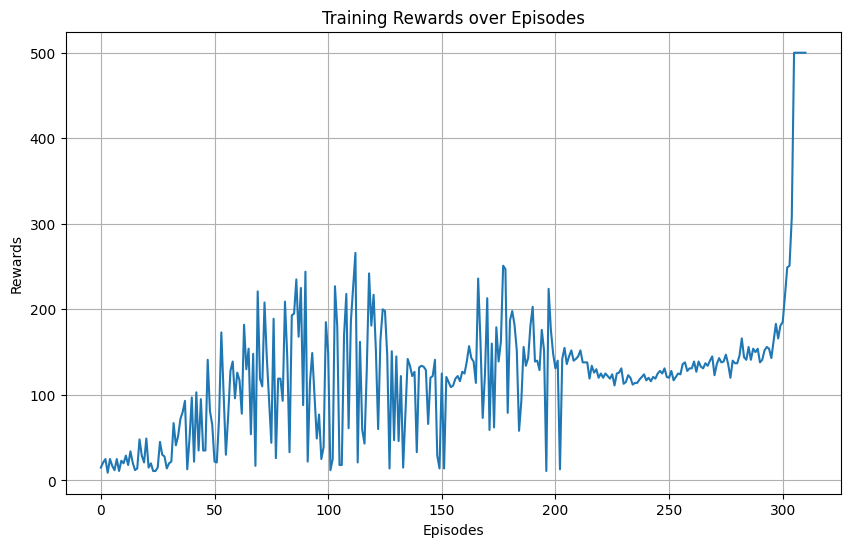

[15.0,
 21.0,
 25.0,
 9.0,
 25.0,
 17.0,
 12.0,
 25.0,
 11.0,
 23.0,
 20.0,
 29.0,
 18.0,
 34.0,
 21.0,
 12.0,
 14.0,
 48.0,
 29.0,
 21.0,
 49.0,
 15.0,
 20.0,
 11.0,
 11.0,
 15.0,
 45.0,
 30.0,
 28.0,
 14.0,
 20.0,
 22.0,
 67.0,
 41.0,
 52.0,
 72.0,
 80.0,
 93.0,
 13.0,
 49.0,
 97.0,
 22.0,
 103.0,
 35.0,
 95.0,
 35.0,
 35.0,
 141.0,
 81.0,
 65.0,
 22.0,
 21.0,
 73.0,
 173.0,
 102.0,
 30.0,
 75.0,
 128.0,
 139.0,
 96.0,
 126.0,
 117.0,
 78.0,
 182.0,
 130.0,
 154.0,
 54.0,
 148.0,
 17.0,
 221.0,
 119.0,
 110.0,
 208.0,
 144.0,
 93.0,
 44.0,
 189.0,
 26.0,
 119.0,
 119.0,
 93.0,
 209.0,
 145.0,
 33.0,
 193.0,
 195.0,
 235.0,
 168.0,
 225.0,
 88.0,
 244.0,
 22.0,
 115.0,
 149.0,
 99.0,
 49.0,
 77.0,
 25.0,
 39.0,
 185.0,
 149.0,
 12.0,
 25.0,
 227.0,
 180.0,
 18.0,
 18.0,
 170.0,
 218.0,
 61.0,
 186.0,
 226.0,
 266.0,
 21.0,
 162.0,
 59.0,
 43.0,
 130.0,
 242.0,
 181.0,
 217.0,
 152.0,
 60.0,
 164.0,
 200.0,
 198.0,
 146.0,
 14.0,
 151.0,
 47.0,
 145.0,
 46.0,
 122.0,
 15.0,
 80.0,
 142

In [61]:
agent = DQLAgent(env)
agent.train(num_episodes=500)  # Train the agent

### Save & Load Trained Model

In [62]:
agent.save_model('dql_cartpole.pth')
print("Model saved to dql_cartpole.pth")
agent.load_model('dql_cartpole.pth')

Model saved to dql_cartpole.pth


C:\Users\Zhao Qixian\AppData\Local\Temp\ipykernel_3260\66799946.py:224: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.q_network.load_state_dict(torch.load(filename))


### Test Trained Agent and Evaluation

Episode 1, Total Reward: 500.0
Episode 2, Total Reward: 500.0
Episode 3, Total Reward: 500.0
Episode 4, Total Reward: 500.0
Episode 5, Total Reward: 500.0
Episode 6, Total Reward: 500.0
Episode 7, Total Reward: 500.0
Episode 8, Total Reward: 500.0
Episode 9, Total Reward: 500.0
Episode 10, Total Reward: 500.0

=== Enhanced Agent Evaluation ===
Evaluation episode 20/100, Reward: 500.0
Evaluation episode 40/100, Reward: 500.0
Evaluation episode 60/100, Reward: 500.0
Evaluation episode 80/100, Reward: 500.0
Evaluation episode 100/100, Reward: 500.0

=== Evaluation Results ===
Average Reward: 500.00
Median Reward: 500.00
Reward Standard Deviation: 0.00
Success Rate (reward ≥ 195): 100.00%
Average Episode Length: 500.00 steps
Action Distribution: Left: 49.98%, Right: 50.02%


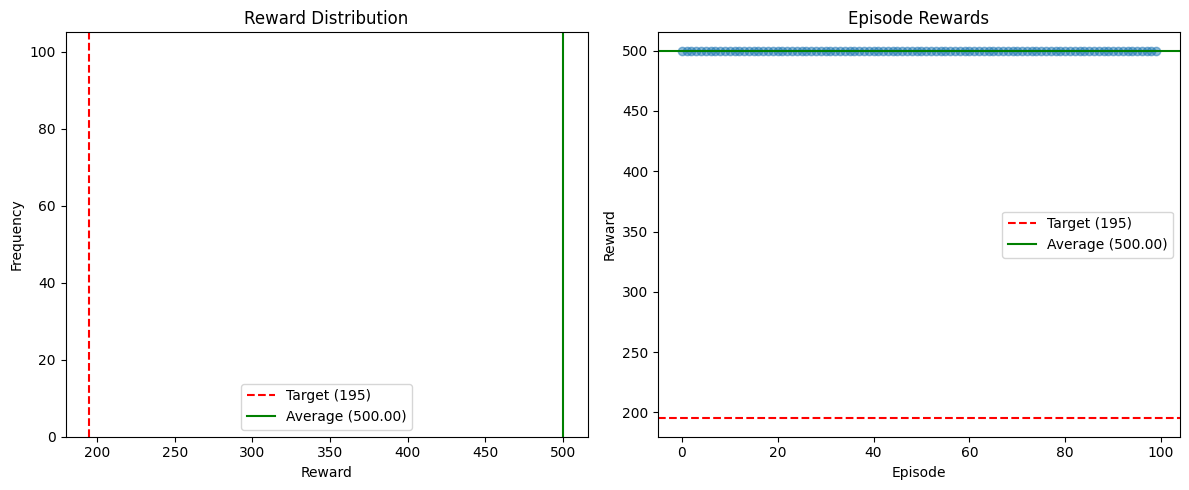


=== Overall Assessment ===
✅ EXCELLENT: Your agent consistently solves the environment!


In [122]:
agent.test(num_episodes=10)
rewards, avg_reward, success_rate, median_reward, reward_std = evaluate_agent(agent, env, num_episodes=100)

### Corectness of Implementation

In [121]:
state = env.reset()

# Check if Gym returns (state, info) or just state
if isinstance(state, tuple):
    state = state[0]  # Gymnasium (state, info)

state = np.array(state, dtype=np.float32).reshape(-1)  # Ensure state is (4,)
action = agent.select_action(state, training=False)
print("State:", state)
print("Action:", action)


State: [ 0.03137833 -0.04059832 -0.03117311  0.02231897]
Action: 1


## 1.2 Hyperparameter Exploration and Tuning

### Vary Learning Rate


Training with Learning Rate = 0.05
Episode 0/10000, Total Reward: 18.0, Epsilon: 0.10
Episode 10/10000, Total Reward: 43.0, Epsilon: 0.09
Episode 20/10000, Total Reward: 10.0, Epsilon: 0.09
Episode 30/10000, Total Reward: 26.0, Epsilon: 0.09
Episode 40/10000, Total Reward: 50.0, Epsilon: 0.08
Episode 50/10000, Total Reward: 17.0, Epsilon: 0.08
Episode 60/10000, Total Reward: 11.0, Epsilon: 0.07
Episode 70/10000, Total Reward: 98.0, Epsilon: 0.07
Episode 80/10000, Total Reward: 137.0, Epsilon: 0.07
Episode 90/10000, Total Reward: 147.0, Epsilon: 0.06
Episode 100/10000, Total Reward: 90.0, Epsilon: 0.06
Episode 110/10000, Total Reward: 197.0, Epsilon: 0.06
Episode 120/10000, Total Reward: 18.0, Epsilon: 0.05
Episode 130/10000, Total Reward: 97.0, Epsilon: 0.05
Episode 140/10000, Total Reward: 102.0, Epsilon: 0.05
Episode 150/10000, Total Reward: 60.0, Epsilon: 0.05
Episode 160/10000, Total Reward: 99.0, Epsilon: 0.04
Episode 170/10000, Total Reward: 109.0, Epsilon: 0.04


KeyboardInterrupt: 

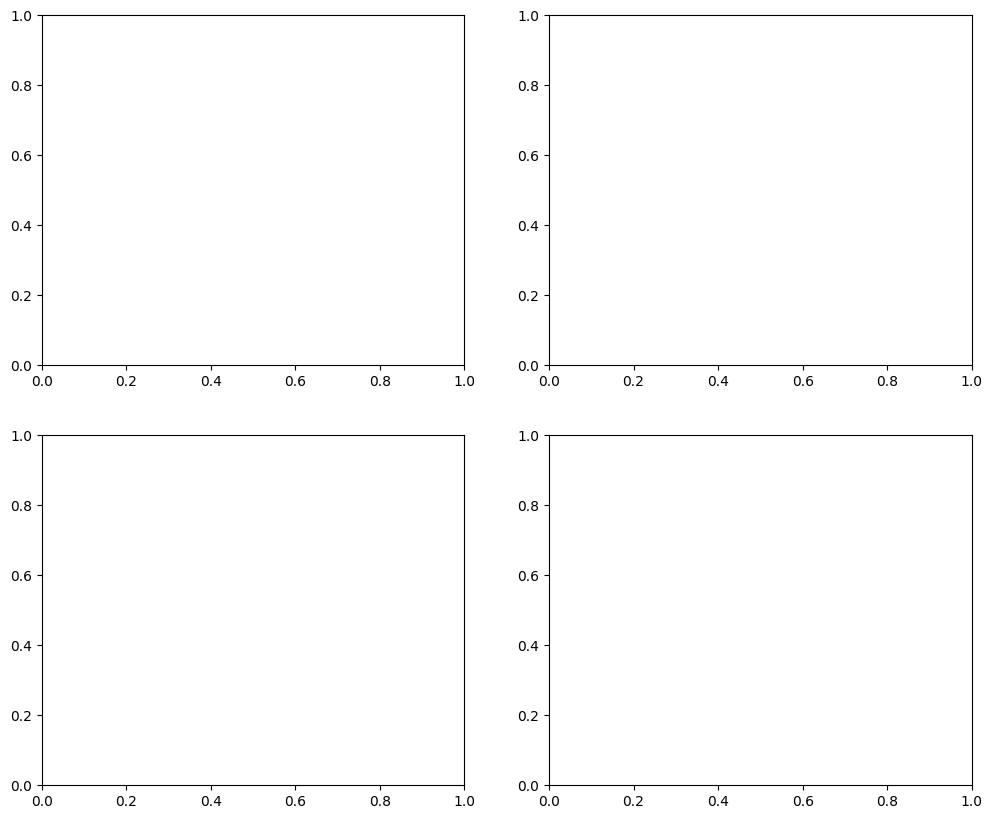

In [18]:
import matplotlib.pyplot as plt
import numpy as np

# Define learning rates to test
learning_rates = [0.05, 0.1, 0.15, 0.2]

# Create subplots for plotting results
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

# Iterate over different learning rates
for i, lr in enumerate(learning_rates):
    print(f"\nTraining with Learning Rate = {lr}")

    # Initialize a new agent for each LR
    agent = DQLAgent(env, lr=lr, epsilon=0.1)  # Keep epsilon constant at 0.1

    # Train the agent and retrieve reward history
    rewards = agent.train(num_episodes=10000)  # Increase episodes to match reference

    # Compute the moving average for smooth plotting
    window_size = 100
    mean_rewards = np.convolve(rewards, np.ones(window_size)/window_size, mode='valid')

    # Plot training rewards
    axes[i].plot(mean_rewards)
    axes[i].set_title(f"Mean Rewards vs Episodes (lr={lr}, er=0.10)")
    axes[i].set_xlabel("Episodes")
    axes[i].set_ylabel("Mean Rewards")

plt.tight_layout()
plt.show()


### Vary Initial Exploration Rate

### Choosing the best hyper parameters